# OMI Transactions Exploration

Exploratory analysis of OMI normalized transaction volumes (NTN) for Italian municipalities, 2011–2025.

The notebook is release-agnostic: it discovers annual files from their filenames, harmonizes year-specific schemas, validates keys before joins, and builds one municipality-year analytical panel for downstream analysis.

## 1. Setup and release discovery

The project root is detected automatically. File parsing uses the explicit OMI pattern `YYYY_LISTA-COM.csv`, `YYYY_VALORI-RES.csv`, `YYYY_VALORI-COM.csv`, `YYYY_VALORI-PER.csv`, avoiding fragile filename slicing.

In [1]:
from pathlib import Path
import re
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

EXPECTED_TABLES = {'LISTA-COM', 'VALORI-RES', 'VALORI-COM', 'VALORI-PER'}
FILENAME_RE = re.compile(r'^(?P<year>\d{4})_(?P<table>LISTA-COM|VALORI-RES|VALORI-COM|VALORI-PER)\.csv$', re.I)

def find_project_root(start=None):
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'raw' / 'transactions').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate data/raw/transactions. Run the notebook from the repository.')

PROJECT_ROOT = find_project_root()
TRANSACTIONS_ROOT = PROJECT_ROOT / 'data' / 'raw' / 'transactions'
print(f'Project root: {PROJECT_ROOT}')
print(f'Transactions root: {TRANSACTIONS_ROOT}')

Project root: C:\Users\cc1323\italian-real-estate-analysis
Transactions root: C:\Users\cc1323\italian-real-estate-analysis\data\raw\transactions


In [2]:
def discover_releases(root):
    records = []
    for path in root.rglob('*.csv'):
        match = FILENAME_RE.match(path.name)
        if match:
            records.append({'year': int(match.group('year')), 'table': match.group('table').upper(), 'path': path})
    catalogue = pd.DataFrame(records)
    if catalogue.empty:
        raise FileNotFoundError(f'No OMI transaction releases found under {root}')
    duplicates = catalogue.duplicated(['year', 'table'], keep=False)
    if duplicates.any():
        raise ValueError('Duplicate year/table combinations found:\n' + catalogue.loc[duplicates].to_string(index=False))
    coverage = catalogue.groupby('year')['table'].agg(lambda x: sorted(set(x))).rename('tables').reset_index()
    coverage['missing_tables'] = coverage['tables'].map(lambda x: sorted(EXPECTED_TABLES - set(x)))
    incomplete = coverage[coverage['missing_tables'].map(bool)]
    if not incomplete.empty:
        print('Warning: incomplete releases detected:')
        print(incomplete.to_string(index=False))
    return catalogue.sort_values(['year', 'table']).reset_index(drop=True)

catalogue = discover_releases(TRANSACTIONS_ROOT)
years = sorted(catalogue['year'].unique())
print(f'Releases discovered: {min(years)}–{max(years)} ({len(years)} years)')
display(catalogue[['year', 'table']].head(20))

Releases discovered: 2011–2025 (15 years)


,year,table
0,2011,LISTA-COM
1,2011,VALORI-COM
2,2011,VALORI-PER
3,2011,VALORI-RES
4,2012,LISTA-COM
5,2012,VALORI-COM
6,2012,VALORI-PER
7,2012,VALORI-RES
8,2013,LISTA-COM
9,2013,VALORI-COM


## 2. Efficient schema harmonization and ingestion

Historical releases use small naming variations (`AREA`/`Area`, `prov`/`Provincia`, year-prefixed NTN fields). Columns are canonicalized and numeric NTN fields are parsed with the Italian decimal convention. The loader caches each release and concatenates once per table.

In [3]:
def normalize_label(value):
    value = unicodedata.normalize('NFKD', str(value)).encode('ascii', 'ignore').decode()
    value = re.sub(r'^\d{4}_', '', value.strip(), flags=re.I)
    value = re.sub(r'^ntn_?\d{4}_?', 'ntn_', value, flags=re.I)
    value = re.sub(r'\s+', '_', value)
    value = re.sub(r'[^0-9A-Za-z_]+', '_', value)
    return re.sub(r'_+', '_', value).strip('_').lower()

def normalize_columns(df):
    df = df.copy()
    df.columns = [normalize_label(c) for c in df.columns]
    return df

def find_column(columns, *patterns):
    for pattern in patterns:
        regex = re.compile(pattern, re.I)
        matches = [c for c in columns if regex.search(c)]
        if matches:
            return matches[0]
    return None

def parse_numeric(series):
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors='coerce')
    return pd.to_numeric(series.astype('string').str.replace('.', '', regex=False).str.replace(',', '.', regex=False), errors='coerce')

def read_omi_csv(path):
    return pd.read_csv(path, sep=';', dtype='string', na_values=['', 'NA', 'N/A', 'nan', '-'], keep_default_na=True)

def load_release_table(path, year, table):
    df = normalize_columns(read_omi_csv(path))
    codcom = find_column(df.columns, r'^codcom$', r'cod_com')
    if codcom is None:
        raise ValueError(f'{path.name}: municipality code column not found')
    df = df.rename(columns={codcom: 'codcom'})
    df['codcom'] = df['codcom'].astype('string').str.strip().str.upper()
    df['year'] = year
    df['table'] = table
    for column in df.columns:
        if column.startswith('ntn'):
            df[column] = parse_numeric(df[column])
    return df

def table_path(year, table):
    match = catalogue[(catalogue.year == year) & (catalogue.table == table)]
    if match.empty:
        raise FileNotFoundError(f'Missing {year}_{table}.csv')
    return Path(match.iloc[0].path)

_TABLE_CACHE = {}
def get_table(year, table):
    key = (year, table)
    if key not in _TABLE_CACHE:
        _TABLE_CACHE[key] = load_release_table(table_path(year, table), year, table)
    return _TABLE_CACHE[key]

tables = {}
for table in sorted(EXPECTED_TABLES):
    available = [y for y in years if not catalogue[(catalogue.year == y) & (catalogue.table == table)].empty]
    if available:
        tables[table] = pd.concat([get_table(y, table) for y in available], ignore_index=True, copy=False)

for table, df in tables.items():
    print(f'{table:10s}: {len(df):>8,} rows × {df.shape[1]:>2} columns')

C:\Users\cc1323\AppData\Local\Temp\ipykernel_22100\1227849051.py:61: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  tables[table] = pd.concat([get_table(y, table) for y in available], ignore_index=True, copy=False)
C:\Users\cc1323\AppData\Local\Temp\ipykernel_22100\1227849051.py:61: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  tables[table] = pd.concat([get_table(y, table) for y in available], ignore_index=True, copy=False)
C:\Users\cc1323\AppData\Local\Temp\ipykernel_22100\1227849051.py:61: Pandas4Warning: The copy keyword is deprecated and will be removed in a future versio

LISTA-COM :  114,262 rows × 11 columns
VALORI-COM:  114,262 rows × 19 columns
VALORI-PER:  114,263 rows ×  9 columns
VALORI-RES:  114,277 rows × 94 columns


## 3. Municipality dimension and residential panel

`LISTA-COM` is the descriptive dimension. The historical `prov` and newer `Provincia` fields are coalesced, while the municipality-year key is explicitly validated.

In [20]:
# ============================================================
# RESIDENTIAL NTN PANEL
# Year-aware extraction from wide VALORI-RES
# ============================================================

import re

import numpy as np
import pandas as pd


# ----------------------------------------------------------------
# 1. Source tables
# ----------------------------------------------------------------

lista = tables['LISTA-COM']
res = tables['VALORI-RES']


# ----------------------------------------------------------------
# 2. Municipality dimension
# ----------------------------------------------------------------

key_columns = ['year', 'codcom']

dimension_candidates = [
    'comune',
    'area',
    'regione',
    'provincia',
    'prov',
    'cap',
    'tag_mercato',
]

dimension_columns = [
    c for c in [*key_columns, *dimension_candidates]
    if c in lista.columns
]

municipality_dim = (
    lista[dimension_columns]
    .sort_values(['year', 'codcom'])
    .drop_duplicates(['year', 'codcom'], keep='last')
    .reset_index(drop=True)
)


# ----------------------------------------------------------------
# 3. Remove invalid technical municipality identifiers
# ----------------------------------------------------------------

INVALID_CODMOM = {
    'NON NATO',
    'NON NATI',
}

municipality_dim = municipality_dim.loc[
    ~municipality_dim['codcom'].isin(INVALID_CODMOM)
].copy()


# ----------------------------------------------------------------
# 4. Normalize textual dimensions
# ----------------------------------------------------------------

for col in ['comune', 'area', 'regione', 'provincia', 'prov', 'tag_mercato']:
    if col in municipality_dim.columns:
        municipality_dim[col] = (
            municipality_dim[col]
            .astype('string')
            .str.strip()
        )


# Harmonize province field if only one of the two exists
if 'provincia' not in municipality_dim.columns and 'prov' in municipality_dim.columns:
    municipality_dim['provincia'] = municipality_dim['prov']

if 'prov' not in municipality_dim.columns and 'provincia' in municipality_dim.columns:
    municipality_dim['prov'] = municipality_dim['provincia']


# ----------------------------------------------------------------
# 5. Helpers for VALORI-RES column detection
# ----------------------------------------------------------------

res_columns = set(res.columns)


def first_existing(candidates):
    """Return the first column existing in VALORI-RES."""
    for candidate in candidates:
        if candidate in res_columns:
            return candidate
    return None


# Standard NTN size categories
SIZE_CANDIDATES = {
    'ntn_upto_50': lambda year: [
        f'ntn_{year}_fino_a_50_mq',
        f'ntn_{year}_fino_a_50',
        'ntn_fino_a_50_mq' if year == 2018 else None,
    ],
    'ntn_50_85': lambda year: [
        f'ntn_{year}_50_85_mq',
        f'ntn_{year}_50_85',
        'ntn_50_85_mq' if year == 2018 else None,
    ],
    'ntn_85_115': lambda year: [
        f'ntn_{year}_85_115_mq',
        f'ntn_{year}_85_115',
        'ntn_85_115_mq' if year == 2018 else None,
    ],
    'ntn_115_145': lambda year: [
        f'ntn_{year}_115_145_mq',
        f'ntn_{year}_115_145',
        'ntn_115_145_mq' if year == 2018 else None,
    ],
    'ntn_over_145': lambda year: [
        f'ntn_{year}_oltre_145_mq',
        f'ntn_{year}_oltre_145',
        'ntn_oltre_145_mq' if year == 2018 else None,
    ],
}


# Remove None candidates
for key, func in SIZE_CANDIDATES.items():
    original_func = func

    def make_clean_func(f):
        def clean(year):
            return [x for x in f(year) if x is not None]
        return clean

    SIZE_CANDIDATES[key] = make_clean_func(original_func)


# ----------------------------------------------------------------
# 6. Year-specific total NTN candidates
# ----------------------------------------------------------------

def total_candidates(year):
    """
    Candidate total columns, accounting for the historical
    naming inconsistencies in VALORI-RES.
    """
    candidates = [
        f'ntn_{year}',
        f'ntn_{year}_totale',
    ]

    # Generic 'ntn' is used by the 2022 structure.
    if year >= 2022:
        candidates.append('ntn')

    return candidates


# ----------------------------------------------------------------
# 7. Build the year-aware residential panel
# ----------------------------------------------------------------

years = sorted(
    pd.to_numeric(res['year'], errors='coerce')
    .dropna()
    .astype(int)
    .unique()
)

res_panel = res[['year', 'codcom']].copy()

# Standard output columns
size_output_columns = [
    'ntn_upto_50',
    'ntn_50_85',
    'ntn_85_115',
    'ntn_115_145',
    'ntn_over_145',
]

for col in size_output_columns:
    res_panel[col] = np.nan

res_panel['ntn_res_source'] = np.nan


# ----------------------------------------------------------------
# 8. Populate each year using the correct source columns
# ----------------------------------------------------------------

column_mapping_log = []

for year in years:

    year_mask = res_panel['year'].eq(year)

    # ------------------------------------------------------------
    # Size classes
    # ------------------------------------------------------------

    for output_col, candidate_function in SIZE_CANDIDATES.items():

        source_col = first_existing(
            candidate_function(year)
        )

        if source_col is None:
            column_mapping_log.append({
                'year': year,
                'field': output_col,
                'source_column': None,
            })
            continue

        values = pd.to_numeric(
            res.loc[year_mask, source_col],
            errors='coerce'
        )

        res_panel.loc[
            year_mask,
            output_col
        ] = values.to_numpy()

        column_mapping_log.append({
            'year': year,
            'field': output_col,
            'source_column': source_col,
        })


    # ------------------------------------------------------------
    # Total NTN
    # ------------------------------------------------------------

    total_col = first_existing(
        total_candidates(year)
    )

    if total_col is not None:

        total_values = pd.to_numeric(
            res.loc[year_mask, total_col],
            errors='coerce'
        )

        res_panel.loc[
            year_mask,
            'ntn_res_source'
        ] = total_values.to_numpy()

        column_mapping_log.append({
            'year': year,
            'field': 'ntn_res',
            'source_column': total_col,
        })

    else:

        column_mapping_log.append({
            'year': year,
            'field': 'ntn_res',
            'source_column': None,
        })


# ----------------------------------------------------------------
# 9. Calculate NTN by size class
# ----------------------------------------------------------------

res_panel['ntn_res_size_sum'] = (
    res_panel[size_output_columns]
    .sum(axis=1, min_count=1)
)


# ----------------------------------------------------------------
# 10. Use reported total when available.
#     Otherwise derive total from size classes.
# ----------------------------------------------------------------

reported_total_available = res_panel['ntn_res_source'].notna()

res_panel['ntn_res'] = np.where(
    reported_total_available,
    res_panel['ntn_res_source'],
    res_panel['ntn_res_size_sum'],
)


# ----------------------------------------------------------------
# 11. Identify whether NTN is reported or derived
# ----------------------------------------------------------------

res_panel['ntn_res_is_derived'] = ~reported_total_available

res_panel['ntn_res_source_type'] = np.where(
    res_panel['ntn_res_is_derived'],
    'derived_from_size_classes',
    'reported',
)


# ----------------------------------------------------------------
# 12. Reconciliation gap
# ----------------------------------------------------------------

res_panel['ntn_res_reconciliation_gap'] = np.where(
    reported_total_available,
    (
        res_panel['ntn_res_source']
        - res_panel['ntn_res_size_sum']
    ),
    np.nan,
)


# ----------------------------------------------------------------
# 13. Remove invalid technical records
# ----------------------------------------------------------------

invalid_mask = res_panel['codcom'].isin(
    INVALID_CODMOM
)

if invalid_mask.any():

    invalid_rows = int(invalid_mask.sum())

    print(
        f"Removing {invalid_rows:,} invalid municipality rows "
        f"with codcom in {sorted(INVALID_CODMOM)}"
    )

    res_panel = res_panel.loc[
        ~invalid_mask
    ].copy()


# ----------------------------------------------------------------
# 14. Validate year + municipality uniqueness
# ----------------------------------------------------------------

duplicate_mask = res_panel.duplicated(
    ['year', 'codcom'],
    keep=False,
)

if duplicate_mask.any():

    duplicate_rows = (
        res_panel.loc[
            duplicate_mask,
            [
                'year',
                'codcom',
                'ntn_res',
                'ntn_res_size_sum',
            ],
        ]
        .sort_values(['year', 'codcom'])
    )

    display(
        duplicate_rows.head(30)
    )

    raise ValueError(
        'Duplicate municipality-year observations detected '
        'after removing invalid municipality identifiers'
    )


# ----------------------------------------------------------------
# 15. Validate required fields
# ----------------------------------------------------------------

if res_panel[['year', 'codcom']].isna().any().any():
    raise ValueError(
        'Missing year/codcom detected in RES panel'
    )

if res_panel['ntn_res'].isna().any():
    missing = int(res_panel['ntn_res'].isna().sum())

    raise ValueError(
        f'{missing:,} rows have no residential NTN value '
        f'after year-aware extraction'
    )


# ----------------------------------------------------------------
# 16. Optimize dtypes
# ----------------------------------------------------------------

res_panel['year'] = (
    pd.to_numeric(
        res_panel['year'],
        errors='coerce'
    )
    .astype('int16')
)

res_panel['codcom'] = (
    res_panel['codcom']
    .astype('string')
    .str.strip()
)


# ----------------------------------------------------------------
# 17. Merge with municipality dimension
# ----------------------------------------------------------------

panel = res_panel.merge(
    municipality_dim,
    on=['year', 'codcom'],
    how='left',
    validate='one_to_one',
)


# ----------------------------------------------------------------
# 18. Optimize categorical dimensions
# ----------------------------------------------------------------

for col in [
    'comune',
    'area',
    'regione',
    'provincia',
    'prov',
    'tag_mercato',
]:

    if col in panel.columns:

        panel[col] = (
            panel[col]
            .astype('string')
            .str.strip()
        )

        # category only when useful
        if panel[col].nunique(
            dropna=True
        ) < len(panel) * 0.5:

            panel[col] = panel[col].astype('category')


# ----------------------------------------------------------------
# 19. Validate merge coverage
# ----------------------------------------------------------------

missing_region = (
    panel['regione'].isna().sum()
    if 'regione' in panel.columns
    else 0
)

missing_region_pct = (
    missing_region / len(panel) * 100
    if len(panel)
    else 0
)

print(
    f"Panel created successfully:"
    f"\n  Rows:          {len(panel):,}"
    f"\n  Municipalities: {panel['codcom'].nunique():,}"
    f"\n  Years:          {panel['year'].nunique()}"
    f"\n  Region missing: {missing_region:,} "
    f"({missing_region_pct:.2f}%)"
)


# ----------------------------------------------------------------
# 20. Year/column mapping audit
# ----------------------------------------------------------------

mapping_audit = (
    pd.DataFrame(column_mapping_log)
    .sort_values(['year', 'field'])
    .reset_index(drop=True)
)

display(mapping_audit)


# ----------------------------------------------------------------
# 21. Final panel preview
# ----------------------------------------------------------------

display(
    panel[
        [
            'year',
            'codcom',
            'ntn_res',
            'ntn_res_size_sum',
            'ntn_res_source_type',
            'ntn_res_reconciliation_gap',
            *[
                c for c in [
                    'comune',
                    'regione',
                    'provincia',
                    'area',
                ]
                if c in panel.columns
            ],
        ]
    ]
    .sort_values(['year', 'codcom'])
    .head(20)
)

Removing 15 invalid municipality rows with codcom in ['NON NATI', 'NON NATO']
Panel created successfully:
  Rows:          114,262
  Municipalities: 7,812
  Years:          15
  Region missing: 0 (0.00%)


,year,field,source_column
0,2011,ntn_115_145,ntn_2011_115_145_mq
1,2011,ntn_50_85,ntn_2011_50_85_mq
2,2011,ntn_85_115,ntn_2011_85_115_mq
3,2011,ntn_over_145,ntn_2011_oltre_145_mq
4,2011,ntn_res,ntn_2011
...,...,...,...
85,2025,ntn_50_85,ntn_2025_50_85_mq
86,2025,ntn_85_115,ntn_2025_85_115_mq
87,2025,ntn_over_145,ntn_2025_oltre_145_mq
88,2025,ntn_res,ntn


,year,codcom,ntn_res,ntn_res_size_sum,ntn_res_source_type,ntn_res_reconciliation_gap,comune,regione,provincia,area
3645,2011,A001,265.11,265.11,reported,0.00,ABANO TERME,Veneto,<NA>,Nord Est
1049,2011,A004,1.00,1.00,reported,0.00,ABBADIA CERRETO,Lombardia,<NA>,Nord Ovest
959,2011,A005,27.83,27.83,reported,0.00,ABBADIA LARIANA,Lombardia,<NA>,Nord Ovest
5031,2011,A006,40.67,40.67,reported,0.00,ABBADIA SAN SALVATORE,Toscana,<NA>,Centro
7157,2011,A007,15.67,15.67,reported,0.00,ABBASANTA,Sardegna,<NA>,Isole
5371,2011,A008,5.00,5.00,reported,0.00,ABBATEGGIO,Abruzzo,<NA>,Sud
1110,2011,A010,353.13,353.13,reported,0.00,ABBIATEGRASSO,Lombardia,<NA>,Nord Ovest
5009,2011,A012,41.51,41.51,reported,-0.00,ABETONE,Toscana,<NA>,Centro
5495,2011,A013,10.00,10.00,reported,0.00,ABRIOLA,Basilicata,<NA>,Sud
7658,2011,A014,51.34,51.34,reported,0.00,ACATE,Sicilia,<NA>,Isole


In [21]:
# ============================================================
# PANEL VALIDATION
# ============================================================

validation = (
    panel
    .groupby('year', as_index=False, observed=True)
    .agg(
        municipalities=('codcom', 'nunique'),
        ntn_res=('ntn_res', 'sum'),
        ntn_res_size_sum=('ntn_res_size_sum', 'sum'),
        reported_rows=(
            'ntn_res_is_derived',
            lambda x: (~x).sum()
        ),
        derived_rows=(
            'ntn_res_is_derived',
            'sum'
        ),
    )
    .sort_values('year')
)

validation['size_gap_reported'] = (
    validation['ntn_res']
    - validation['ntn_res_size_sum']
)

validation['yoy_pct'] = (
    validation['ntn_res']
    .pct_change()
    .mul(100)
)

display(
    validation.style.format({
        'ntn_res': '{:,.2f}',
        'ntn_res_size_sum': '{:,.2f}',
        'size_gap_reported': '{:,.2f}',
        'yoy_pct': '{:,.1f}%',
    })
)

,year,municipalities,ntn_res,ntn_res_size_sum,reported_rows,derived_rows,size_gap_reported,yoy_pct
0,2011,7715,"575,797.10","575,797.10",7715,0,0.00,nan%
1,2012,7715,"427,566.36","427,566.36",7715,0,0.00,-25.7%
2,2013,7698,"389,447.90","389,447.90",7698,0,0.00,-8.9%
3,2014,7665,"405,721.52","405,721.52",7665,0,0.00,4.2%
4,2015,7661,"435,931.25","435,931.25",7661,0,0.00,7.4%
5,2016,7645,"517,184.41","517,184.41",7645,0,0.00,18.6%
6,2017,7624,"543,187.68","543,187.68",7624,0,0.00,5.0%
7,2018,7603,"579,207.17","579,207.17",7603,0,0.00,6.6%
8,2019,7564,"604,167.77","604,167.77",7564,0,0.00,4.3%
9,2020,7562,"558,721.59","558,721.59",7562,0,0.00,-7.5%


## 4. National and regional residential dynamics

All aggregates now derive from the same municipality-year panel, eliminating repeated raw-data joins.

In [22]:
# ============================================================
# NATIONAL RESIDENTIAL NTN
# ============================================================

national = (
    panel
    .groupby(
        'year',
        as_index=False,
        observed=True,
    )
    .agg(
        ntn_res=('ntn_res', 'sum'),
        ntn_res_size_sum=('ntn_res_size_sum', 'sum'),
        municipalities=('codcom', 'nunique'),
    )
    .sort_values('year')
    .reset_index(drop=True)
)

national['size_gap'] = (
    national['ntn_res']
    - national['ntn_res_size_sum']
)

national['yoy_pct'] = (
    national['ntn_res']
    .pct_change()
    .mul(100)
)

display(
    national.style.format({
        'ntn_res': '{:,.0f}',
        'ntn_res_size_sum': '{:,.0f}',
        'size_gap': '{:,.2f}',
        'yoy_pct': '{:,.1f}%',
    })
)

,year,ntn_res,ntn_res_size_sum,municipalities,size_gap,yoy_pct
0,2011,"575,797","575,797",7715,0.00,nan%
1,2012,"427,566","427,566",7715,0.00,-25.7%
2,2013,"389,448","389,448",7698,0.00,-8.9%
3,2014,"405,722","405,722",7665,0.00,4.2%
4,2015,"435,931","435,931",7661,0.00,7.4%
5,2016,"517,184","517,184",7645,0.00,18.6%
6,2017,"543,188","543,188",7624,0.00,5.0%
7,2018,"579,207","579,207",7603,0.00,6.6%
8,2019,"604,168","604,168",7564,0.00,4.3%
9,2020,"558,722","558,722",7562,0.00,-7.5%


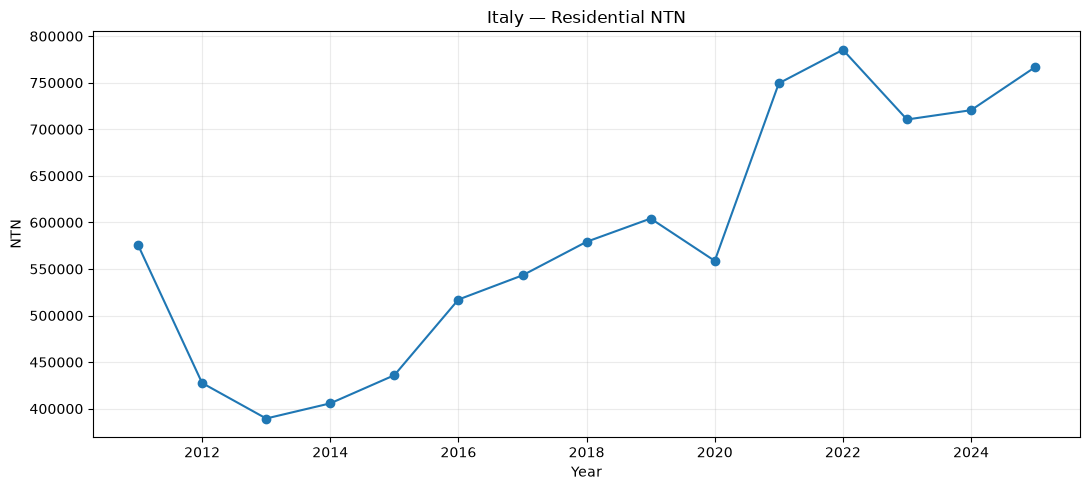

In [23]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    national['year'],
    national['ntn_res'],
    marker='o',
)

ax.set(
    title='Italy — Residential NTN',
    xlabel='Year',
    ylabel='NTN',
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# REGIONAL RESIDENTIAL NTN
# ============================================================

regional = (
    panel
    .dropna(subset=['regione'])
    .groupby(
        ['year', 'regione'],
        as_index=False,
        observed=True,
    )
    .agg(
        ntn_res=('ntn_res', 'sum'),
        municipalities=('codcom', 'nunique'),
    )
    .sort_values(['regione', 'year'])
    .reset_index(drop=True)
)

regional['yoy_pct'] = (
    regional
    .groupby('regione', observed=True)['ntn_res']
    .pct_change()
    .mul(100)
)


# ------------------------------------------------------------
# Latest year
# ------------------------------------------------------------

latest_year = int(regional['year'].max())

top_regions = (
    regional[
        regional['year'].eq(latest_year)
    ]
    .nlargest(10, 'ntn_res')
    .sort_values('ntn_res', ascending=False)
)

display(
    top_regions.style.format({
        'ntn_res': '{:,.0f}',
        'yoy_pct': '{:,.1f}%',
    })
)

,year,regione,ntn_res,municipalities,yoy_pct
134,2025,Lombardia,"162,189",1500,7.0%
104,2025,Lazio,"73,830",378,5.6%
179,2025,Piemonte,"70,932",1180,10.1%
74,2025,Emilia-Romagna,"68,348",330,7.3%
284,2025,Veneto,"67,159",556,5.2%
224,2025,Sicilia,"53,590",391,7.0%
239,2025,Toscana,"51,566",273,9.4%
59,2025,Campania,"43,874",549,3.3%
194,2025,Puglia,"43,461",256,-0.9%
119,2025,Liguria,"28,327",234,8.2%


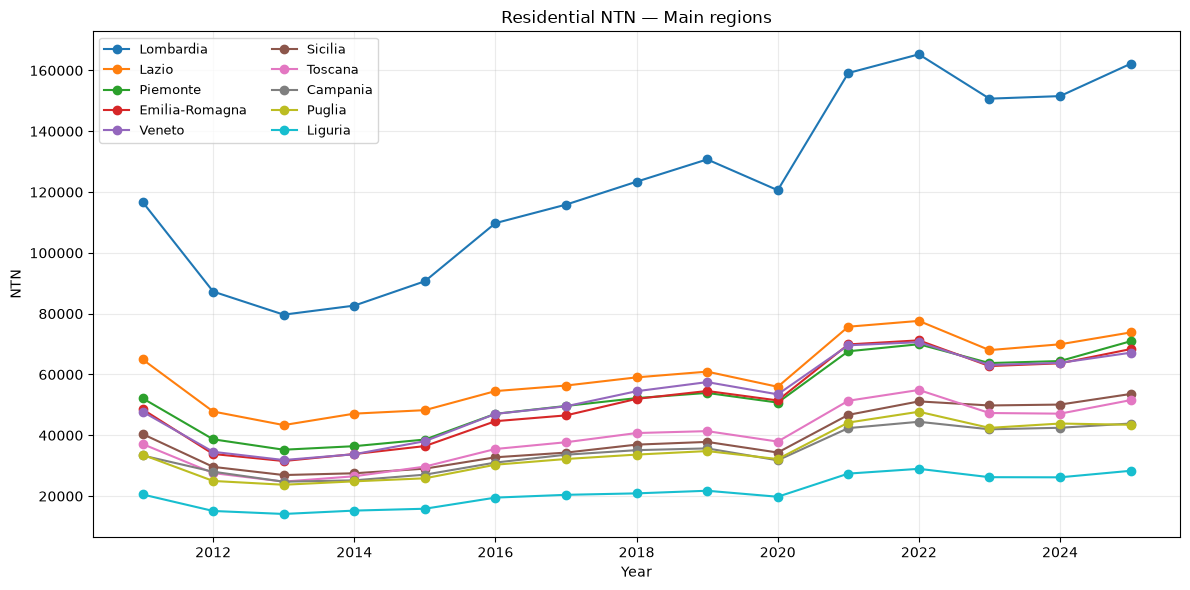

In [25]:
fig, ax = plt.subplots(figsize=(12, 6))

for region in top_regions['regione']:
    subset = regional[
        regional['regione'].eq(region)
    ]

    ax.plot(
        subset['year'],
        subset['ntn_res'],
        marker='o',
        label=region,
    )

ax.set(
    title='Residential NTN — Main regions',
    xlabel='Year',
    ylabel='NTN',
)

ax.legend(
    ncol=2,
    fontsize=9,
)

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 5. Residential size mix

The five official residential size bands are reshaped into a compact time series. The official total NTN remains the authoritative volume measure; the band sum is a reconciliation check.

,year,size_band,ntn,share_pct
29,2025,50–85 m²,"236,295",30.8%
44,2025,85–115 m²,"203,863",26.6%
74,2025,Over 145 m²,"133,674",17.4%
59,2025,115–145 m²,"119,873",15.6%
14,2025,Up to 50 m²,"73,053",9.5%


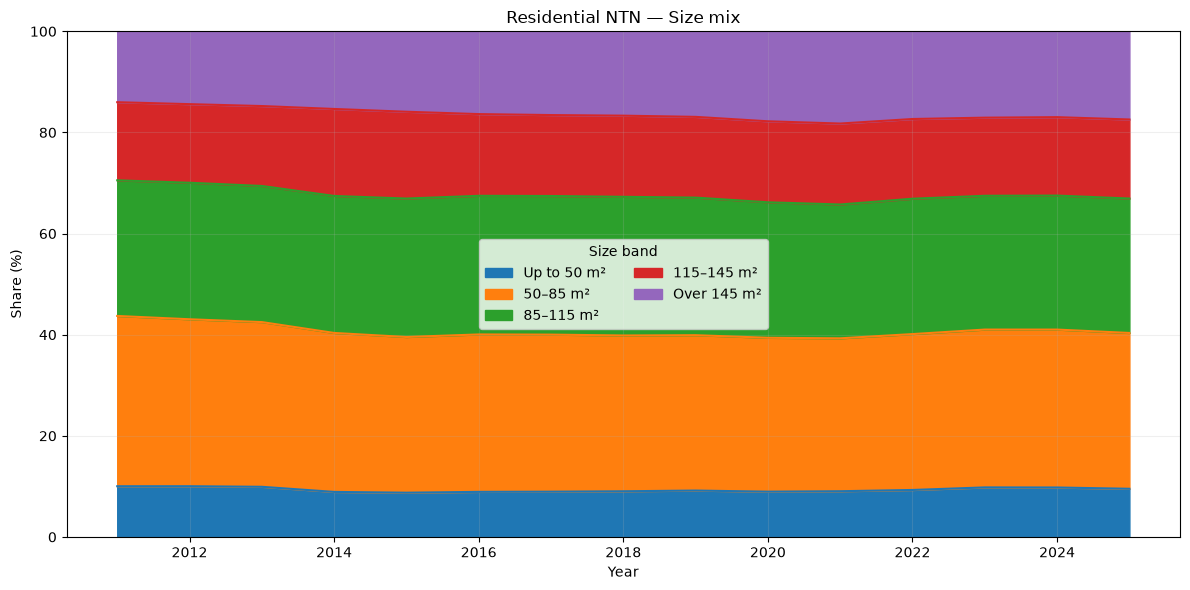

In [27]:
# ============================================================
# RESIDENTIAL NTN — SIZE MIX
# ============================================================

size_fields = [
    'ntn_upto_50',
    'ntn_50_85',
    'ntn_85_115',
    'ntn_115_145',
    'ntn_over_145',
]


# ------------------------------------------------------------
# 1. Aggregate NTN by year and size band
# ------------------------------------------------------------

size_long = (
    panel
    .groupby(
        'year',
        as_index=False,
        observed=True,
    )[size_fields]
    .sum()
    .melt(
        id_vars='year',
        var_name='size_band',
        value_name='ntn',
    )
)


# ------------------------------------------------------------
# 2. Human-readable size-band labels
# ------------------------------------------------------------

size_labels = {
    'ntn_upto_50': 'Up to 50 m²',
    'ntn_50_85': '50–85 m²',
    'ntn_85_115': '85–115 m²',
    'ntn_115_145': '115–145 m²',
    'ntn_over_145': 'Over 145 m²',
}

size_long['size_band'] = (
    size_long['size_band']
    .map(size_labels)
)


# ------------------------------------------------------------
# 3. Calculate annual size mix
# ------------------------------------------------------------

size_long['year_total'] = (
    size_long
    .groupby('year', observed=True)['ntn']
    .transform('sum')
)

size_long['share_pct'] = np.where(
    size_long['year_total'].gt(0),
    size_long['ntn']
    .div(size_long['year_total'])
    .mul(100),
    np.nan,
)


# ------------------------------------------------------------
# 4. Latest-year composition
# ------------------------------------------------------------

latest_size_mix = (
    size_long[
        size_long['year'].eq(latest_year)
    ]
    .sort_values(
        'share_pct',
        ascending=False,
    )
)

display(
    latest_size_mix[
        ['year', 'size_band', 'ntn', 'share_pct']
    ].style.format({
        'ntn': '{:,.0f}',
        'share_pct': '{:,.1f}%',
    })
)


# ------------------------------------------------------------
# 5. Pivot for chart
# ------------------------------------------------------------

mix = (
    size_long
    .pivot(
        index='year',
        columns='size_band',
        values='share_pct',
    )
    .sort_index()
)


# Keep a logical size order
ordered_labels = [
    'Up to 50 m²',
    '50–85 m²',
    '85–115 m²',
    '115–145 m²',
    'Over 145 m²',
]

mix = mix.reindex(
    columns=[
        col for col in ordered_labels
        if col in mix.columns
    ]
)


# ------------------------------------------------------------
# 6. Stacked area chart
# ------------------------------------------------------------

ax = mix.plot(
    kind='area',
    stacked=True,
    figsize=(12, 6),
)

ax.set(
    title='Residential NTN — Size mix',
    xlabel='Year',
    ylabel='Share (%)',
)

ax.set_ylim(0, 100)

ax.legend(
    title='Size band',
    ncol=2,
)

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [28]:
# ============================================================
# SIZE MIX VALIDATION
# ============================================================

mix_check = (
    size_long
    .groupby('year', observed=True)['share_pct']
    .sum()
    .reset_index(name='total_share_pct')
)

display(
    mix_check.style.format({
        'total_share_pct': '{:,.2f}%',
    })
)

,year,total_share_pct
0,2011,100.00%
1,2012,100.00%
2,2013,100.00%
3,2014,100.00%
4,2015,100.00%
5,2016,100.00%
6,2017,100.00%
7,2018,100.00%
8,2019,100.00%
9,2020,100.00%


## 6. Non-residential reconciliation

`VALORI-COM` and `VALORI-PER` are aggregated through their normalized `ntn_*` fields, without hard-coding every historical category name.

In [29]:
non_res_frames = []
for table in ['VALORI-COM', 'VALORI-PER']:
    if table not in tables:
        continue
    df = tables[table]
    ntn_columns = [c for c in df.columns if c.startswith('ntn_')]
    if not ntn_columns:
        continue
    frame = df[['year', 'codcom', *ntn_columns]].copy()
    frame['ntn_non_res'] = frame[ntn_columns].sum(axis=1, min_count=1)
    non_res_frames.append(frame[['year', 'codcom', 'ntn_non_res']])

non_res = pd.concat(non_res_frames, ignore_index=True) if non_res_frames else pd.DataFrame(columns=['year', 'codcom', 'ntn_non_res'])
non_res = non_res.groupby(['year', 'codcom'], as_index=False).agg(ntn_non_res=('ntn_non_res', 'sum'))

market_panel = panel.merge(non_res, on=['year', 'codcom'], how='left', validate='one_to_one')
market_panel['ntn_non_res'] = market_panel['ntn_non_res'].fillna(0)

reconciliation = market_panel.groupby('year', as_index=False, observed=True).agg(ntn_res=('ntn_res', 'sum'), ntn_non_res=('ntn_non_res', 'sum'))
reconciliation['ntn_all_loaded'] = reconciliation.ntn_res + reconciliation.ntn_non_res
display(reconciliation.style.format({'ntn_res': '{:,.0f}', 'ntn_non_res': '{:,.0f}', 'ntn_all_loaded': '{:,.0f}'}))

,year,ntn_res,ntn_non_res,ntn_all_loaded
0,2011,"575,797","540,903","1,116,700"
1,2012,"427,566","408,736","836,303"
2,2013,"389,448","373,619","763,067"
3,2014,"405,722","376,537","782,258"
4,2015,"435,931","393,603","829,535"
5,2016,"517,184","464,741","981,926"
6,2017,"543,188","491,872","1,035,060"
7,2018,"579,207","519,263","1,098,470"
8,2019,"604,168","547,910","1,152,078"
9,2020,"558,722","523,629","1,082,350"


## 7. Final municipality-year analytical panel

This compact object is the hand-off for downstream price-volume and market-dynamics notebooks. It is built once and avoids reloading and rejoining the raw releases.

In [30]:
panel_columns = ['year', 'codcom', *[c for c in ['comune', 'provincia', 'regione', 'area', 'cap', 'tag_mercato'] if c in market_panel.columns], 'ntn_res', *size_fields, 'ntn_non_res']
market_panel = market_panel[panel_columns].sort_values(['year', 'regione', 'provincia', 'comune', 'codcom']).reset_index(drop=True)

assert not market_panel.duplicated(['year', 'codcom']).any()
assert market_panel['ntn_res'].ge(0).all()
assert market_panel['codcom'].notna().all()

print(f'Final municipality-year panel: {len(market_panel):,} rows')
print(f'Unique municipalities: {market_panel.codcom.nunique():,}')
print(f'Years: {market_panel.year.min()}–{market_panel.year.max()}')
display(market_panel.head(10))

Final municipality-year panel: 114,262 rows
Unique municipalities: 7,812
Years: 2011–2025


,year,codcom,comune,provincia,regione,area,cap,ntn_res,ntn_upto_50,ntn_50_85,ntn_85_115,ntn_115_145,ntn_over_145,ntn_non_res
0,2011,A008,ABBATEGGIO,<NA>,Abruzzo,Sud,<NA>,5.00,2.00,0.00,2.00,0.00,1.00,2.00
1,2011,A018,ACCIANO,<NA>,Abruzzo,Sud,<NA>,3.00,1.00,0.00,0.00,0.00,2.00,0.00
2,2011,A100,AIELLI,<NA>,Abruzzo,Sud,<NA>,7.56,2.00,1.00,3.00,1.56,0.00,4.00
3,2011,A120,ALANNO,<NA>,Abruzzo,Sud,<NA>,17.97,1.00,3.75,2.50,3.11,7.61,11.33
4,2011,A125,ALBA ADRIATICA,<NA>,Abruzzo,Sud,<NA>,283.04,61.72,159.31,36.61,15.50,9.90,325.94
5,2011,A187,ALFEDENA,<NA>,Abruzzo,Sud,<NA>,48.72,8.00,34.00,4.50,1.00,1.22,26.12
6,2011,A235,ALTINO,<NA>,Abruzzo,Sud,<NA>,30.34,2.00,1.00,14.00,5.00,8.34,35.68
7,2011,A270,ANCARANO,<NA>,Abruzzo,Sud,<NA>,10.09,1.00,1.00,0.00,1.48,6.61,8.61
8,2011,A318,ANVERSA DEGLI ABRUZZI,<NA>,Abruzzo,Sud,<NA>,2.17,0.00,0.50,0.00,0.67,1.00,4.50
9,2011,A367,ARCHI,<NA>,Abruzzo,Sud,<NA>,11.75,0.00,3.00,4.00,2.75,2.00,8.75


## 8. Data-quality checks

The notebook fails early if the release catalogue, municipality-year uniqueness, municipality keys or non-negative residential NTN assumptions are violated.

In [31]:
checks = pd.Series({
    'release_catalogue_not_empty': not catalogue.empty,
    'years_detected': len(years) >= 1,
    'municipality_year_unique': not market_panel.duplicated(['year', 'codcom']).any(),
    'residential_non_negative': bool(market_panel.ntn_res.ge(0).all()),
    'no_missing_municipality_code': bool(market_panel.codcom.notna().all()),
}, name='passed')
display(checks.to_frame())
if not checks.all():
    raise AssertionError(f'Data-quality checks failed: {checks[~checks].index.tolist()}')
print('All data-quality checks passed.')

,passed
release_catalogue_not_empty,True
years_detected,True
municipality_year_unique,True
residential_non_negative,True
no_missing_municipality_code,True


All data-quality checks passed.
